<a href="https://colab.research.google.com/github/MottaDavide/MaskArchitectureAnomaly_CourseProject/blob/main/eomt/inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

### Configure the loop to evaluate the model

Set EVAL_SINGLE to FALSE if you want to evaluate the COCO-trained or Cityscapes-trained model on the full validation set (cityscapes val).

You can select the model i the Setup. 

If you only want to visualize one picture, set EVAL_SINGLE to True

In [1]:
# Evaluation configuration
# Select which classes to use for evaluation
# Select whether to run a loop or visualize a single image

# True = only visualize one selected image (img_idx) and skip full quantitative evaluation | False = evaluate the full Cityscapes validation set
EVAL_SINGLE = False  

## Setup

In [2]:
# Environment prepared by 00_setup on the same Colab runtime: only mount Drive and set the working directory here.
# The repository and dependencies are managed by 00_setup.ipynb. Run it first.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    import os, sys
    REPO = "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject"
    os.chdir(REPO + "/eomt")               # so the setup cell resolves paths on Drive
    sys.path.insert(0, REPO + "/eomt")
except ImportError:
    pass   # local execution: the setup cell below handles paths


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
from pathlib import Path

MODEL = "coco" # "coco" or "cityscapes"

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab")
    PROJECT_ROOT = Path.cwd()
    MYDRIVE_ROOT = PROJECT_ROOT.parents[1]
    DATA_ROOT = MYDRIVE_ROOT / "FAIML_project_and_presentation" / "01_Project" / "large_files" / "datasets"
    WEIGHTS_ROOT = MYDRIVE_ROOT / "FAIML_project_and_presentation" / "01_Project" / "large_files" / "weights"
    
else:
    print("Running locally")
    PROJECT_ROOT = Path.cwd()
    DATA_ROOT = PROJECT_ROOT / "datasets"
    WEIGHTS_ROOT = PROJECT_ROOT / "weights"

os.chdir(PROJECT_ROOT)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("WEIGHTS_ROOT:", WEIGHTS_ROOT)

CITYSCAPES_ROOT = DATA_ROOT / "cityscapes"
COCO_ROOT = DATA_ROOT / "coco"

Running on Colab
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject/eomt
DATA_ROOT: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/datasets
WEIGHTS_ROOT: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/weights


In [4]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = "cuda:0" if torch.cuda.is_available() else "cpu"      # set the GPU, or "cpu" (slower)

img_idx = 5  

if MODEL == "coco":
    config_path = PROJECT_ROOT / "configs" / "dinov2" / "coco" / "panoptic" / "eomt_base_640_2x.yaml"
    ckpt_path   = WEIGHTS_ROOT/"eomt_coco.bin"
else:
    config_path = PROJECT_ROOT / "configs" / "dinov2" / "cityscapes" / "semantic" / "eomt_base_640.yaml"
    ckpt_path   = WEIGHTS_ROOT/"eomt_cityscapes.bin"

data_config_path = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml" 
data_path = DATA_ROOT /"cityscapes"
zip_path = DATA_ROOT / "coco" / "panoptic_annotations_trainval2017.zip"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

with open(data_config_path, "r") as f:
    data_config = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [5]:
import sys, os, importlib

EOMT = os.getcwd() 
for sub in ("", "datasets"):
    init = os.path.join(EOMT, sub, "__init__.py")
    if not os.path.exists(init):
        open(init, "a").close()
sys.path.insert(0, EOMT)
for _m in [m for m in sys.modules if m == "datasets" or m.startswith("datasets.")]:
    del sys.modules[_m]

import datasets as _ds
assert os.path.realpath(EOMT) in os.path.realpath(_ds.__file__), (
    f"`datasets` risolve la libreria HF ({_ds.__file__}), non il pacchetto locale in {EOMT}"
)

data_module_name, class_name = "datasets.cityscapes_semantic.CityscapesSemantic".rsplit(".", 1)

data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = {}

model_img_size = (640, 640) if MODEL == "coco" else (1024, 1024)

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    img_size=model_img_size,
    **data_module_kwargs
).setup()

model_num_classes = 133 if MODEL == "coco" else data.num_classes

print("Dataset class:", data_module)
print("Data path:", data_path)
print("Data path exists:", data_path.exists())
print("Model:", MODEL)
print("Image size:", model_img_size)
print("Dataset num_classes:", data.num_classes)
print("Model num_classes:", model_num_classes)

Dataset class: <class 'datasets.cityscapes_semantic.CityscapesSemantic'>
Data path: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/datasets/cityscapes
Data path exists: True
Model: coco
Image size: (640, 640)
Dataset num_classes: 19
Model num_classes: 133


## Load model

In [6]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=model_num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=model_num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [7]:

if os.path.exists(ckpt_path):
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    print("Pesi caricati localmente da:", ckpt_path)
else:
    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

    if name is None:
        warnings.warn("No logger name found in the config. Please specify a model name.")
    else:
        try:
            state_dict_path = hf_hub_download(
                repo_id=f"tue-mps/{name}",
                filename="pytorch_model.bin",
            )

            is_dinov3 = "dinov3" in name

            if is_dinov3:
                model_kwargs["ckpt_path"] = state_dict_path
                model_kwargs["delta_weights"] = True

            model = (
                lit_cls(
                    img_size=data.img_size,
                    num_classes= model_num_classes,    
                    network=network,
                    **model_kwargs,
                )
                .eval()
                .to(device)
            )

            if not is_dinov3:
                state_dict = torch.load(
                    state_dict_path, map_location=f"cuda:{device}", weights_only=True
                )
                model.load_state_dict(state_dict, strict=False)

        except RepositoryNotFoundError:
            warnings.warn(
                f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
            )

Pesi caricati localmente da: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/weights/eomt_coco.bin


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
IGNORE_INDEX = 255


def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if MODEL == "cityscapes":
    img, target = data.val_dataloader().dataset[img_idx]
    pred_array, target_array = infer_semantic(img, target)
    plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

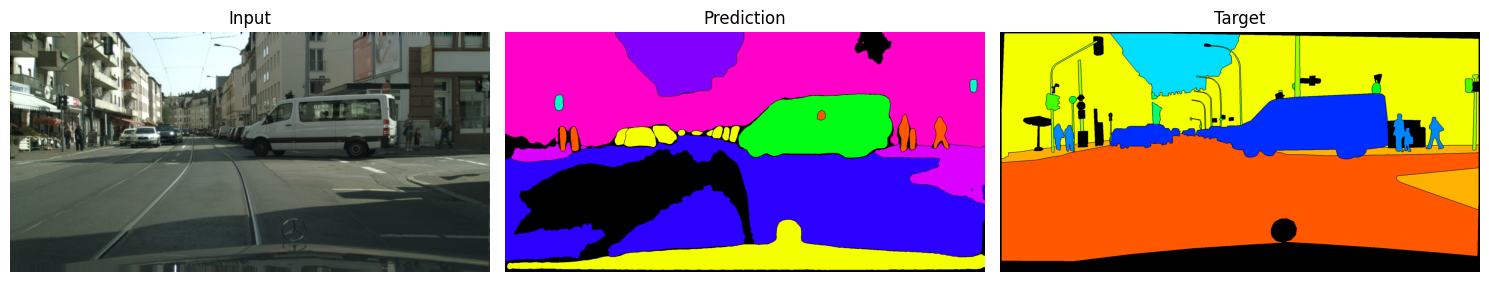

In [ ]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if MODEL == "coco":
    img, target = data.val_dataloader().dataset[img_idx]
    sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
    plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)

## Mapping COCO to Cityscapes

This will map the COCO classes to the Cityscapes classes in preparation for the evaluation loop (on the cityscapes validation set). 

In [ ]:
# This cell creates a table of the Cityscapes classes used for evaluation.
# It filters out ignored classes and stores, for each valid class, 
# the model index (train_id), the class name, and the original dataset ID.
# The result helps interpret predictions and evaluation metrics.

import pandas as pd
from torchvision.datasets import Cityscapes

rows = []

for cls in Cityscapes.classes:
    if not cls.ignore_in_eval:
        rows.append({
            "model_id": cls.train_id,
            "name": cls.name,
            "original_id": cls.id
        })

df_cs = pd.DataFrame(rows).sort_values("model_id")

df_cs.style.hide(axis="index")

model_id,name,original_id
0,road,7
1,sidewalk,8
2,building,11
3,wall,12
4,fence,13
5,pole,17
6,traffic light,19
7,traffic sign,20
8,vegetation,21
9,terrain,22


In [8]:
# This cell builds a table of the COCO classes used by the model.
# It reads the annotation file, keeps only the classes present in CLASS_MAPPING, 
# and records their model index, original COCO ID, name, and type (thing or stuff).
# This is useful to understand the model’s output space and how it maps to Cityscapes.

import json
import zipfile
from pathlib import Path
import pandas as pd

from datasets.coco_panoptic import CLASS_MAPPING


with zipfile.ZipFile(zip_path) as z:
    with z.open("annotations/panoptic_val2017.json") as f:
        coco_data  = json.load(f)


print("COCO PANOPTIC - id usati dal modello")
print("-" * 80)

rows = []

for cat in coco_data["categories"]:
    coco_original_id = cat["id"]
    name = cat["name"]
    isthing = cat["isthing"]

    if coco_original_id in CLASS_MAPPING:
        model_id = CLASS_MAPPING[coco_original_id]
        rows.append((model_id, coco_original_id, name, isthing))

rows = sorted(rows, key=lambda x: x[0])


df = pd.DataFrame(rows, columns=["model_id", "coco_id", "name", "isthing"])
df.style.hide(axis="index")

COCO PANOPTIC - id usati dal modello
--------------------------------------------------------------------------------


model_id,coco_id,name,isthing
0,1,person,1
1,2,bicycle,1
2,3,car,1
3,4,motorcycle,1
4,5,airplane,1
5,6,bus,1
6,7,train,1
7,8,truck,1
8,9,boat,1
9,10,traffic light,1


In [ ]:
# Display the COCO -> Cityscapes mapping used by the shared evaluation utilities.
# The actual mapping logic is implemented in eval/cityscapes_eval_utils.py.

from eval.cityscapes_eval_utils import COCO_TO_CITYSCAPES_RAW

if EVAL_SINGLE:
    print("EVAL_SINGLE=True: mapping table is not needed for the full evaluation.")
else:
    df_coco_to_cityscapes = pd.DataFrame(
        [
            {
                "coco_model_id": coco_id,
                "cityscapes_train_id": cs_id,
                "cityscapes_class": CS_NAMES[cs_id],
            }
            for coco_id, cs_id in COCO_TO_CITYSCAPES_RAW.items()
        ]
    ).sort_values(["cityscapes_train_id", "coco_model_id"])

    display(df_coco_to_cityscapes)

NameError: name 'CS_NAMES' is not defined

## COCO vs Cityscapes comparison

This section evaluates both models on the full Cityscapes validation set using the same semantic evaluation protocol.

The COCO-trained model predicts classes in the COCO panoptic label space, so its logits are projected to the Cityscapes train-id space using the shared COCO → Cityscapes mapping implemented in `eval/cityscapes_eval_utils.py`. When multiple COCO classes map to the same Cityscapes class, the maximum logit is used.

The Cityscapes-trained model already predicts Cityscapes semantic classes and is evaluated directly.

For a fair comparison, the same three classes are excluded for both models: `pole`, `traffic sign`, and `rider`. Therefore, the reported mIoU is computed over 16 Cityscapes classes.

The section produces:

- a side-by-side per-class comparison table, including COCO IoU, Cityscapes IoU, and their delta;
- an mIoU / pixel accuracy summary;
- the Excel file `task4_comparison.xlsx` saved in the `results/` directory.

If `EVAL_SINGLE=True`, the full quantitative comparison is skipped and the notebook is used only for single-image visualization/debugging.

In [9]:
# Shared evaluation utilities

import gc
import pandas as pd

from eval.cityscapes_eval_utils import (
    CS_NAMES,
    DEFAULT_TASK4_EXCLUDED_CLASSES,
    build_eomt_eval_model,
    build_cityscapes_val_dataset,
    evaluate_cityscapes_semantic,
    make_iou_tables,
)

EVAL_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
EVAL_EXCLUDE_CLASSES = DEFAULT_TASK4_EXCLUDED_CLASSES

# Use one common validation preprocessing for the quantitative comparison.
# The model-specific windowing logic inside EoMT will still use each model's own img_size.
EVAL_IMG_SIZE = (1024, 1024)

RESULTS = (DATA_ROOT.parents[1] if IN_COLAB else PROJECT_ROOT) / "results/task4"
RESULTS.mkdir(parents=True, exist_ok=True)

print("Evaluation device:", EVAL_DEVICE)
print("Evaluation image size:", EVAL_IMG_SIZE)
print("Excluded classes:", [CS_NAMES[c] for c in EVAL_EXCLUDE_CLASSES])
print("Results directory:", RESULTS)

Evaluation device: cuda:0
Evaluation image size: (1024, 1024)
Excluded classes: ['pole', 'traffic sign', 'rider']
Results directory: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/results/task4


In [ ]:
# Cityscapes validation dataset for the final quantitative comparison

if EVAL_SINGLE:
    print("EVAL_SINGLE=True: skipping the full validation dataset construction.")
    eval_dataset = None
else:
    eval_dataset = build_cityscapes_val_dataset(
        data_cls="datasets.cityscapes_semantic.CityscapesSemantic",
        data_path=DATA_ROOT / "cityscapes",
        img_size=EVAL_IMG_SIZE,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
    )

    print("Validation images:", len(eval_dataset))

Validation images: 500


In [10]:
# Models to compare in Task 4

TASK4_MODELS = {
    "coco": {
        "config": PROJECT_ROOT / "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
        "weights": WEIGHTS_ROOT / "eomt_coco.bin",
        "num_classes": 133,
        "output_space": "coco",
        "img_size": (640, 640),
        "description": "COCO-trained EoMT projected to Cityscapes classes",
    },
    "cityscapes": {
        "config": PROJECT_ROOT / "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
        "weights": WEIGHTS_ROOT / "eomt_cityscapes.bin",
        "num_classes": 19,
        "output_space": "cityscapes",
        "img_size": (1024, 1024),
        "description": "Cityscapes-trained EoMT",
    },
}

for name, info in TASK4_MODELS.items():
    print(f"{name}")
    print("description:", info["description"])
    print("config:", info["config"], "| exists:", info["config"].exists())
    print("weights:", info["weights"], "| exists:", info["weights"].exists())

coco
description: COCO-trained EoMT projected to Cityscapes classes
config: /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml | exists: True
weights: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/weights/eomt_coco.bin | exists: True
cityscapes
description: Cityscapes-trained EoMT
config: /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml | exists: True
weights: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/large_files/weights/eomt_cityscapes.bin | exists: True


In [ ]:
# Full quantitative evaluation on Cityscapes validation

if EVAL_SINGLE:
    print("EVAL_SINGLE=True: skipping the full quantitative comparison.")
    task4_results = {}
else:
    task4_results = {}

    for model_name, info in TASK4_MODELS.items():
        print("" + "=" * 80)
        print(f"Evaluating: {model_name}")
        print(info["description"])
        print("=" * 80)

        assert info["config"].exists(), f"Missing config: {info['config']}"
        assert info["weights"].exists(), f"Missing weights: {info['weights']}"

        model_eval = build_eomt_eval_model(
            config_path=info["config"],
            weights_path=info["weights"],
            img_size=info["img_size"],
            num_classes=info["num_classes"],
            device=EVAL_DEVICE,
            force_masked_attn_enabled=False,
        )

        per_class_iou, miou, pixel_acc = evaluate_cityscapes_semantic(
            model=model_eval,
            dataset=eval_dataset,
            output_space=info["output_space"],
            excluded_classes=EVAL_EXCLUDE_CLASSES,
            device=EVAL_DEVICE,
            model_name=model_name,
        )

        task4_results[model_name] = {
            "description": info["description"],
            "per_class_iou": per_class_iou,
            "miou": miou,
            "pixel_acc": pixel_acc,
        }

        print(f"{model_name} | mIoU={miou:.2f}% | pixel_acc={pixel_acc:.2f}%")

        del model_eval
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

Evaluating: coco
COCO-trained EoMT projected to Cityscapes classes
[coco] 50/500 images processed
[coco] 100/500 images processed
[coco] 150/500 images processed
[coco] 200/500 images processed
[coco] 250/500 images processed
[coco] 300/500 images processed
[coco] 350/500 images processed
[coco] 400/500 images processed
[coco] 450/500 images processed
[coco] 500/500 images processed
coco | mIoU=67.01% | pixel_acc=93.39%
Evaluating: cityscapes
Cityscapes-trained EoMT
[cityscapes] 50/500 images processed
[cityscapes] 100/500 images processed
[cityscapes] 150/500 images processed
[cityscapes] 200/500 images processed
[cityscapes] 250/500 images processed
[cityscapes] 300/500 images processed
[cityscapes] 350/500 images processed
[cityscapes] 400/500 images processed
[cityscapes] 450/500 images processed
[cityscapes] 500/500 images processed
cityscapes | mIoU=83.74% | pixel_acc=97.04%


In [ ]:
# Build and save comparison tables

if not task4_results:
    print("No quantitative results were produced because EVAL_SINGLE=True.")
else:
    df_summary, df_per_class = make_iou_tables(
        results=task4_results,
        excluded_classes=EVAL_EXCLUDE_CLASSES,
    )

    df_per_class["delta (cityscapes - coco) (%)"] = (
        df_per_class["IoU cityscapes (%)"] - df_per_class["IoU coco (%)"]
    )

    display(df_summary)
    display(df_per_class)

    print("=== Summary ===")
    print(df_summary.to_string(index=False))

    print("=== Per-class IoU, evaluated classes only ===")
    print(
        df_per_class[~df_per_class["excluded"]][
            [
                "class_name",
                "IoU coco (%)",
                "IoU cityscapes (%)",
                "delta (cityscapes - coco) (%)",
            ]
        ].to_string(index=False)
    )

    out_xlsx = RESULTS / "task4_comparison.xlsx"
    with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
        df_summary.to_excel(writer, sheet_name="summary", index=False)
        df_per_class.to_excel(writer, sheet_name="per_class_iou", index=False)

    print("Comparison saved to:", out_xlsx)

,model,description,mIoU (%),pixel_acc (%)
0,coco,COCO-trained EoMT projected to Cityscapes classes,67.009132,93.386477
1,cityscapes,Cityscapes-trained EoMT,83.738152,97.036976


,class_id,class_name,excluded,IoU coco (%),IoU cityscapes (%),delta (cityscapes - coco) (%)
0,0,road,False,94.258400,98.439095,4.180695
1,1,sidewalk,False,66.446617,87.638618,21.192001
2,2,building,False,90.823112,94.792145,3.969032
3,3,wall,False,46.634735,66.252228,19.617493
4,4,fence,False,51.772285,66.530045,14.757759
5,5,pole,True,0.000000,0.000000,0.000000
6,6,traffic light,False,63.297127,77.809731,14.512604
7,7,traffic sign,True,0.000000,0.000000,0.000000
8,8,vegetation,False,90.318123,93.474953,3.156830
9,9,terrain,False,56.916367,67.162666,10.246300


=== Summary ===
     model                                       description  mIoU (%)  pixel_acc (%)
      coco COCO-trained EoMT projected to Cityscapes classes 67.009132      93.386477
cityscapes                           Cityscapes-trained EoMT 83.738152      97.036976
=== Per-class IoU, evaluated classes only ===
   class_name  IoU coco (%)  IoU cityscapes (%)  delta (cityscapes - coco) (%)
         road     94.258400           98.439095                       4.180695
     sidewalk     66.446617           87.638618                      21.192001
     building     90.823112           94.792145                       3.969032
         wall     46.634735           66.252228                      19.617493
        fence     51.772285           66.530045                      14.757759
traffic light     63.297127           77.809731                      14.512604
   vegetation     90.318123           93.474953                       3.156830
      terrain     56.916367           67.162666 

## Qualitative comparison (saved images)

For a few fixed Cityscapes validation images, this section renders and saves a
side-by-side qualitative comparison: `Input | Ground truth | COCO (projected to
19 Cityscapes classes) | Cityscapes`.

All panels use the **fixed official Cityscapes palette** with a shared legend,
so the same class always has the same color across images and models. The PNGs
are written to `results/qualitative/`. This runs independently of `EVAL_SINGLE`.


In [16]:
# Save qualitative comparison images (same images for COCO and Cityscapes).

from eval.cityscapes_eval_utils import (
    cityscapes_palette,
    save_qualitative_comparison,
    semantic_logits,
)

# Toggle and image selection. The same indices are used for both models so the
# saved figures show identical scenes side by side.
SAVE_QUALITATIVE = True
QUALITATIVE_INDICES = [3, 8, 15]

# Predictions are kept in the SAME 16-class common space as the mIoU table
# (pole / traffic sign / rider are dropped before argmax). The ground truth is
# left untouched with all 19 classes as a complete visual reference.
QUAL_EXCLUDE_CLASSES = EVAL_EXCLUDE_CLASSES

if not SAVE_QUALITATIVE:
    print("SAVE_QUALITATIVE=False: skipping qualitative image export.")
else:
    QUAL_DIR = RESULTS / "qualitative"
    QUAL_DIR.mkdir(parents=True, exist_ok=True)

    # Build a Cityscapes val dataset at the common eval size if not already built.
    qual_dataset = eval_dataset if ("eval_dataset" in globals() and eval_dataset is not None) else None
    if qual_dataset is None:
        qual_dataset = build_cityscapes_val_dataset(
            data_cls="datasets.cityscapes_semantic.CityscapesSemantic",
            data_path=DATA_ROOT / "cityscapes",
            img_size=EVAL_IMG_SIZE,
            batch_size=1,
            num_workers=0,
            check_empty_targets=False,
        )

    palette = cityscapes_palette()
    excluded = list(QUAL_EXCLUDE_CLASSES)
    print("Ground truth: all 19 classes. Predictions restricted to 16 common classes; excluded:",
          [CS_NAMES[c] for c in excluded])

    # Load both models once, run them on the selected images, then free them.
    qual_models = {}
    for model_name, info in TASK4_MODELS.items():
        qual_models[model_name] = build_eomt_eval_model(
            config_path=info["config"],
            weights_path=info["weights"],
            img_size=info["img_size"],
            num_classes=info["num_classes"],
            device=EVAL_DEVICE,
            force_masked_attn_enabled=False,
        )

    saved = []
    for idx in QUALITATIVE_INDICES:
        img, target = qual_dataset[idx]

        # Ground truth in Cityscapes train-id space, kept with all 19 classes.
        any_model = next(iter(qual_models.values()))
        gt = any_model.to_per_pixel_targets_semantic([target], 255)[0].cpu().numpy()

        predictions = {}
        for model_name, info in TASK4_MODELS.items():
            logits = semantic_logits(
                model=qual_models[model_name],
                img=img,
                output_space=info["output_space"],
                device=EVAL_DEVICE,
            )
            # Drop the excluded class channels before argmax so predictions live
            # in the same 16-class common space (no pole / traffic sign / rider).
            for class_id in excluded:
                logits[class_id] = float("-inf")
            predictions[model_name] = logits.argmax(0).cpu().numpy()

        out_path = QUAL_DIR / f"task4_qualitative_idx{idx:04d}.png"
        save_qualitative_comparison(
            image=img,
            ground_truth=gt,
            predictions=predictions,
            save_path=out_path,
            palette=palette,
            title=f"Cityscapes val #{idx}",
        )
        saved.append(out_path)
        print("Saved:", out_path)

    # Free the models.
    del qual_models
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"\n{len(saved)} qualitative comparison image(s) saved to: {QUAL_DIR}")

Ground truth: all 19 classes. Predictions restricted to 16 common classes; excluded: ['pole', 'traffic sign', 'rider']
Saved: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/results/task4/qualitative/task4_qualitative_idx0003.png
Saved: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/results/task4/qualitative/task4_qualitative_idx0008.png
Saved: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/results/task4/qualitative/task4_qualitative_idx0015.png

3 qualitative comparison image(s) saved to: /content/drive/MyDrive/FAIML_project_and_presentation/01_Project/results/task4/qualitative
